# Act 2 - Ai đang làm rò rỉ biên lợi nhuận?

**Câu hỏi trung tâm:** Khuyến mãi có thật sự kéo về khách hàng tốt, hay chỉ tạo sản lượng rẻ với hiệu quả kinh tế kém?

Trọng tâm là kiểm tra hiệu quả từng chương trình khuyến mãi và chất lượng nhóm khách hàng đi kèm. Hành vi trả hàng là kiểm định phụ; bằng chứng chính nằm ở tỷ lệ mua lại và lợi nhuận gộp trên mỗi khách hàng.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


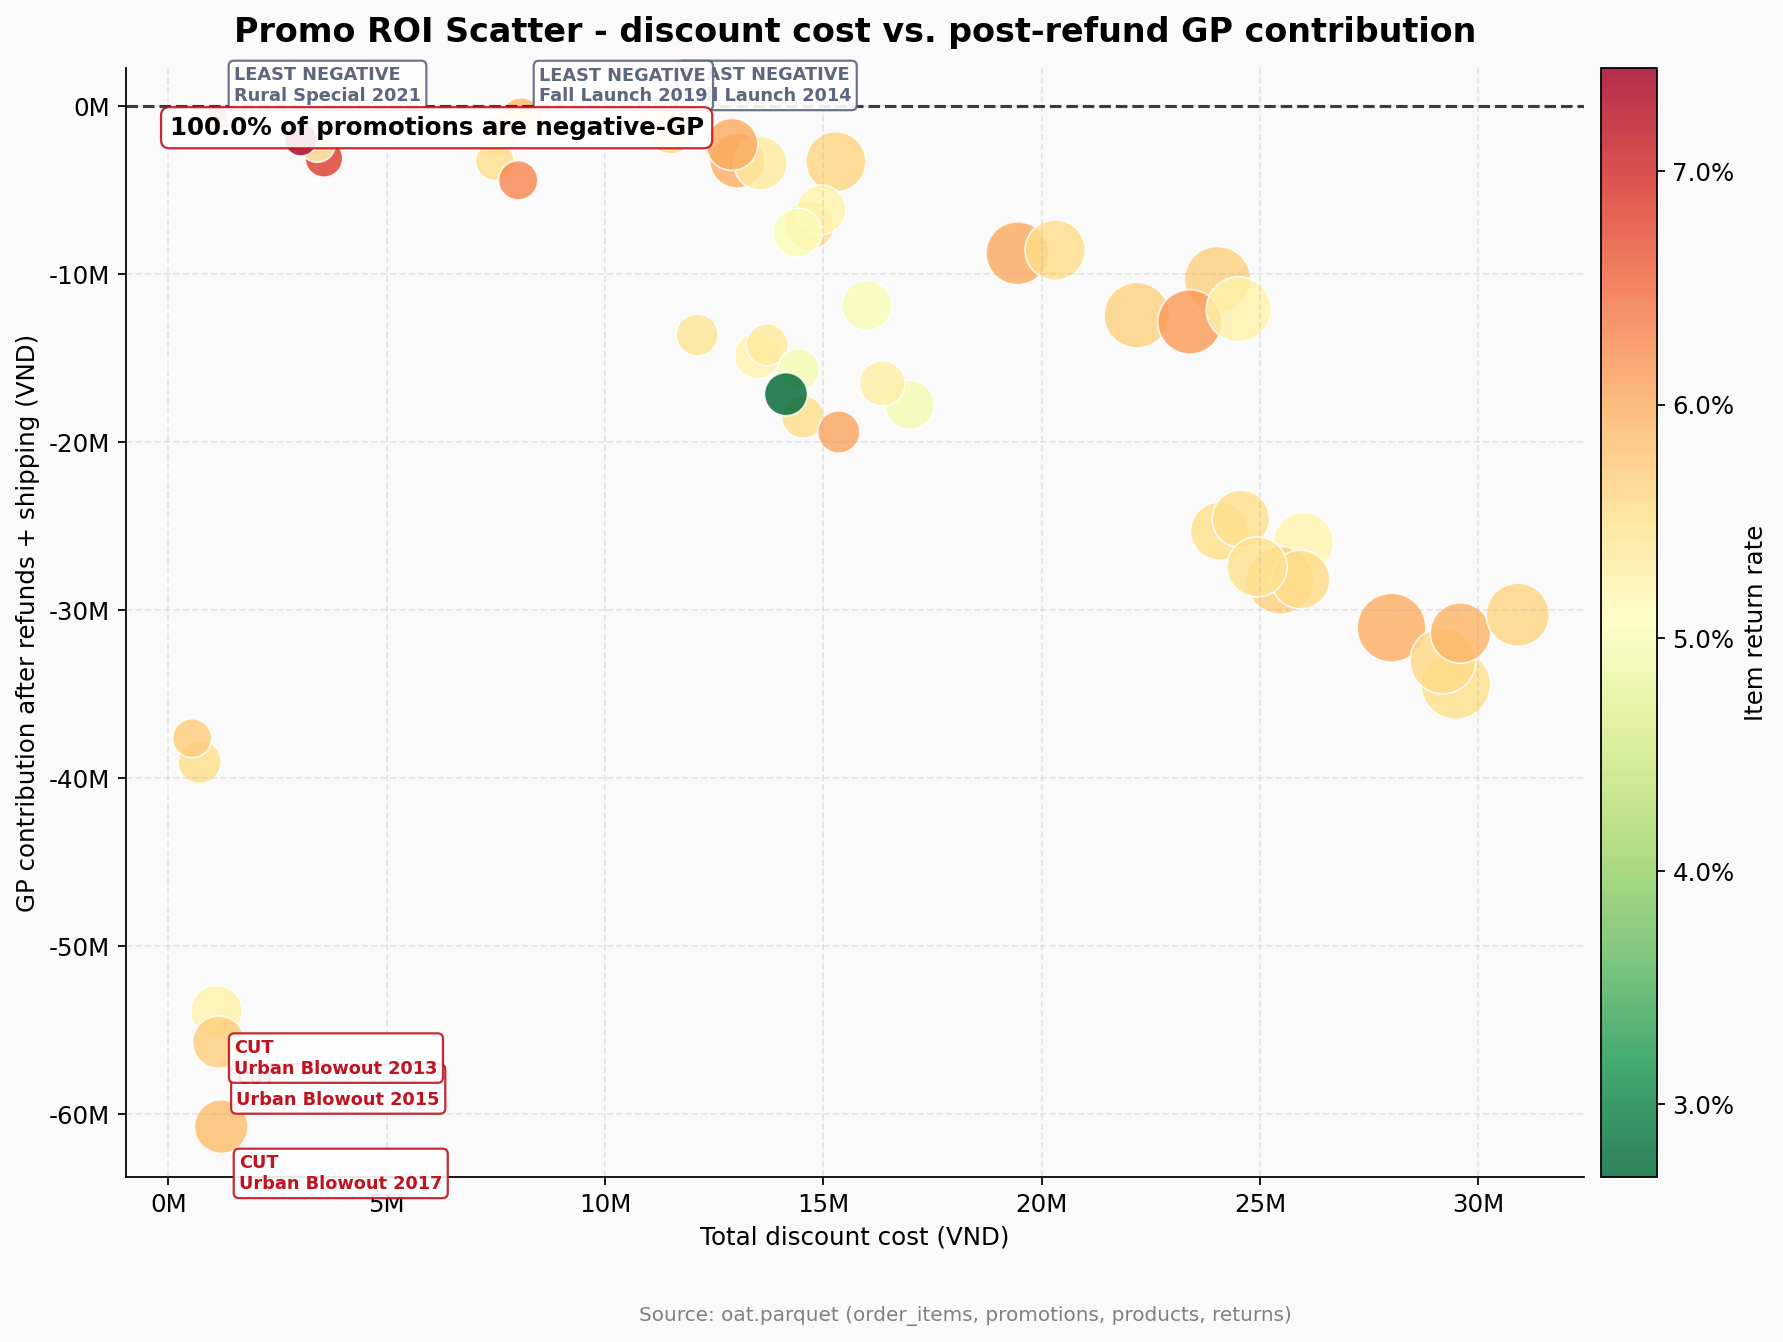

In [2]:
display(Image(str(CHARTS / "chart3_promo_roi_scatter.png"), width=950))


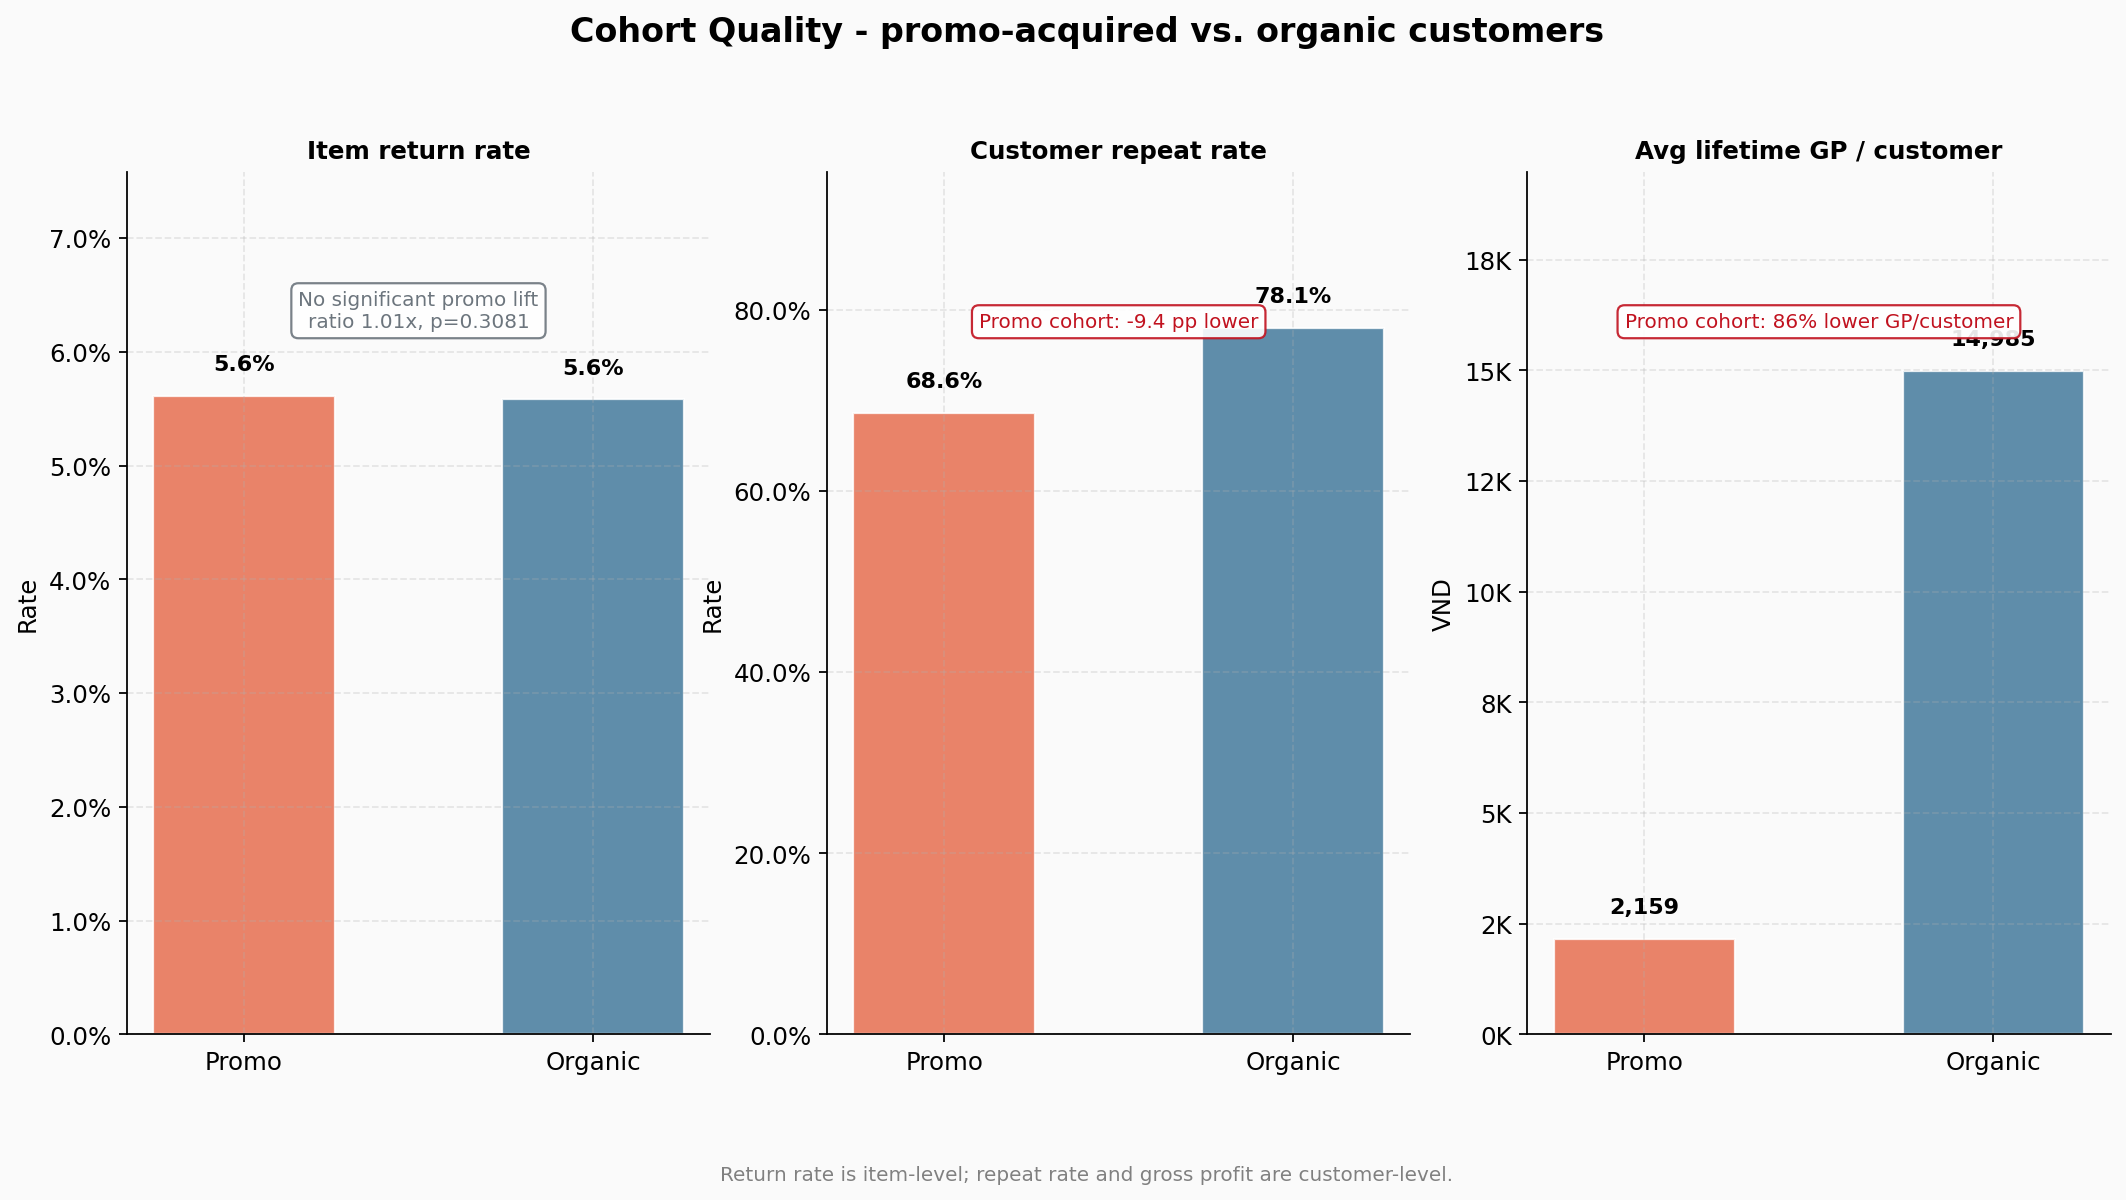

In [3]:
display(Image(str(CHARTS / "chart4_cohort_quality.png"), width=950))


In [4]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
cohort = pd.read_csv(TABLES / "cohort_quality_table.csv")
print(f"Tỷ lệ chương trình có đóng góp lợi nhuận gộp âm: {(triage['total_net_contribution'] < 0).mean() * 100:.1f}%")
cohort_display = cohort.copy()
cohort_display["metric"] = cohort_display["metric"].replace({
    "item_return_rate": "ty_le_tra_hang",
    "customer_repeat_rate": "ty_le_mua_lai",
    "avg_lifetime_gp_per_customer": "loi_nhuan_gop_vong_doi_moi_khach",
})
cohort_display = cohort_display.rename(columns={
    "metric": "chi_so",
    "promo": "nhom_khuyen_mai",
    "organic": "nhom_tu_nhien",
    "difference": "chenh_lech",
})
display(cohort_display)


Tỷ lệ chương trình có đóng góp lợi nhuận gộp âm: 100.0%


,chi_so,nhom_khuyen_mai,nhom_tu_nhien,chenh_lech
0,ty_le_tra_hang,0.056157,0.055817,0.000341
1,ty_le_mua_lai,0.686391,0.780608,-0.094217
2,loi_nhuan_gop_vong_doi_moi_khach,2158.906127,14985.089993,-12826.183867


## Phân tích

Sau khi tính hoàn tiền và phí vận chuyển, **100.0% chương trình khuyến mãi có đóng góp lợi nhuận gộp âm**. Đây là kết quả rất mạnh: toàn bộ mẫu khuyến mãi lịch sử trong dữ liệu đều không qua được ngưỡng lợi nhuận gộp.

Phân tích nhóm khách hàng cho thấy **tỷ lệ trả hàng của khách đến từ khuyến mãi không cao hơn một cách có ý nghĩa thống kê**: nhóm khuyến mãi **5.6%**, nhóm tự nhiên **5.6%**, Mann-Whitney một phía **p = 0.3081**. Vì vậy không nên nói khuyến mãi làm tỷ lệ trả hàng tăng.

Luận điểm chính đến từ hai chỉ số khác:

- Tỷ lệ mua lại của khách hàng: nhóm khuyến mãi **68.6%** so với nhóm tự nhiên **78.1%**.
- Lợi nhuận gộp vòng đời trên mỗi khách hàng sau hoàn tiền và phí vận chuyển: nhóm khuyến mãi **2,159 VND** so với nhóm tự nhiên **14,985 VND**, thấp hơn **86%**.

**Kết luận Act 2:** Tác hại của khuyến mãi chủ yếu đến từ biên lợi nhuận bị nén và hiệu quả kinh tế khách hàng yếu, không phải từ hành vi trả hàng.
